# Chapter 4. NumPy: Fast Numbers

*Data Analytics with Python and Jupyter Notebook*

Companion notebook. Run each cell in order with **Shift + Enter**, and read the chapter alongside it.

## 4.1 Why NumPy?

In Chapter 3 you stored numbers in Python lists. Lists are flexible, but they were not designed for math. Try doubling a list of prices:

In [1]:
prices = [3.00, 4.50, 4.25, 4.75, 3.25, 2.95]
prices * 2

[3.0, 4.5, 4.25, 4.75, 3.25, 2.95, 3.0, 4.5, 4.25, 4.75, 3.25, 2.95]

That is not what you wanted. Multiplying a list by 2 **repeats** it. To actually double each price, you need a loop or a list comprehension:

In [2]:
[p * 2 for p in prices]

[6.0, 9.0, 8.5, 9.5, 6.5, 5.9]

**NumPy** (short for *Numerical Python*) fixes both problems. It gives Python a new kind of container, the **array**, that holds numbers of one type packed tightly together in memory and does math on all of them at once. Here is the same calculation with NumPy:

In [3]:
import numpy as np

prices = np.array([3.00, 4.50, 4.25, 4.75, 3.25, 2.95])
prices * 2

array([6. , 9. , 8.5, 9.5, 6.5, 5.9])

## 4.2 Creating arrays

### From a Python list

The most common way to make an array is to hand `np.array()` a list. Here are the quantities of each product the Downtown store sold on 1 January 2026, in our usual product order (Espresso, Latte, Cappuccino, Cold Brew, Croissant, Blueberry Muffin):

In [4]:
quantities = np.array([30, 53, 35, 14, 26, 21])
quantities

array([30, 53, 35, 14, 26, 21])

Every array knows a few things about itself. The most useful are its **shape**, its number of dimensions, its size, and its **data type** (dtype):

In [5]:
print("shape:", quantities.shape)
print("ndim: ", quantities.ndim)
print("size: ", quantities.size)
print("dtype:", quantities.dtype)

shape: (6,)
ndim:  1
size:  6
dtype: int64


The shape `(6,)` means "one dimension with 6 values". (The trailing comma is how Python writes a tuple with one item.) `int64` means each value is a 64-bit whole number. Our `prices` array, which holds decimals, has a different dtype:

In [6]:
prices.dtype

dtype('float64')

### One type per array

Unlike a list, an array holds values of **one type only**. If you mix types, NumPy converts everything to a type that can hold all of them:

In [7]:
np.array([1, 2, 3.5])

array([1. , 2. , 3.5])

The whole numbers became decimals (`1.` is NumPy's short way of writing `1.0`). Mix in text and everything becomes text, which is rarely what you want:

In [8]:
np.array([1, 2, "three"])

array(['1', '2', 'three'], dtype='<U21')

### Arrays from scratch

In [9]:
days = np.arange(1, 8)
print(days)
print(np.linspace(0, 1, 5))
print(np.zeros(3))
print(np.ones(3, dtype=int))

[1 2 3 4 5 6 7]
[0.   0.25 0.5  0.75 1.  ]
[0. 0. 0.]
[1 1 1]


### Random numbers

Simulated data is handy for practice and for testing ideas. NumPy's random number **generator** produces it. Always create one with a **seed**, a fixed starting number, so that you (and your readers) get the same "random" numbers every time you run the notebook:

In [10]:
rng = np.random.default_rng(42)
rng.integers(10, 60, size=7)

array([14, 48, 42, 31, 31, 52, 14])

## 4.3 Vectorized operations

### Arithmetic between arrays

We have quantities and prices for the six products, in the same order. Revenue is quantity times price, so:

In [11]:
revenue = quantities * prices
revenue

array([ 90.  , 238.5 , 148.75,  66.5 ,  84.5 ,  61.95])

### Arithmetic with a single number

When one side is a single number (a **scalar**), it applies to every element. Suppose Bean There is considering a 10% price rise:

In [12]:
new_prices = prices * 1.10
new_prices

array([3.3  , 4.95 , 4.675, 5.225, 3.575, 3.245])

A latte at $4.95 is fine, but $4.675 is not a price anyone can charge. Round to two decimal places with `np.round()`:

In [13]:
np.round(new_prices, 2)

array([3.3 , 4.95, 4.68, 5.22, 3.58, 3.25])

### Universal functions

For example, here is how far each product's quantity is from 30, ignoring direction:

In [14]:
np.abs(quantities - 30)

array([ 0, 23,  5, 16,  4,  9])

### Comparisons

Comparison operators are vectorized too. Each one returns an array of `True` and `False` values, called a **boolean array**:

In [15]:
quantities > 25

array([ True,  True,  True, False,  True, False])

Booleans have a neat property: `True` counts as 1 and `False` as 0. So summing a boolean array **counts** how many values passed the test:

In [16]:
(quantities > 25).sum()

np.int64(4)

## 4.4 Indexing, slicing, and masks

### Picking single values

Arrays use the same zero-based positions as lists. The first element is `[0]`, and negative positions count from the end:

In [17]:
print(quantities[0])   # Espresso
print(quantities[1])   # Latte
print(quantities[-1])  # Blueberry Muffin

30
53
21


### Slicing

A slice `[start:stop]` takes a range of positions, stopping **before** `stop`. The first four products are the coffees and the last two are bakery items:

In [18]:
coffee = quantities[:4]
bakery = quantities[4:]
print(coffee, bakery)

[30 53 35 14] [26 21]


You can also pick several arbitrary positions at once by passing a **list** of positions. This is called **fancy indexing**:

In [19]:
quantities[[1, 3]]  # Latte and Cold Brew

array([53, 14])

### Boolean masks

The most powerful way to select values is with a boolean array, often called a **mask**. Put the mask inside the square brackets and NumPy keeps only the values where the mask is `True`:

In [20]:
big_sellers = quantities > 25
quantities[big_sellers]

array([30, 53, 35, 26])

You will usually write the condition directly inside the brackets. Read the line below as "quantities where quantities is greater than 25":

In [21]:
quantities[quantities > 25]

array([30, 53, 35, 26])

A mask can come from a **different** array, as long as it has the same length. This keeps the prices of products that sold more than 25 units:

In [22]:
prices[quantities > 25]

array([3.  , 4.5 , 4.25, 3.25])

To combine conditions, use `&` (and), `|` (or) and `~` (not), and wrap each condition in parentheses:

In [23]:
quantities[(quantities > 20) & (quantities < 40)]

array([30, 35, 26, 21])

### Choosing between two values with `np.where`

`np.where(condition, value_if_true, value_if_false)` builds a new array by choosing, element by element, between two options. It is the vectorized version of an `if`/`else`:

In [24]:
np.where(quantities > 25, "busy", "quiet")

array(['busy', 'busy', 'busy', 'quiet', 'busy', 'quiet'], dtype='<U5')

### Views and copies

One behavior catches almost everyone. A **slice** of an array is a **view**: a window onto the same numbers, not a separate copy. Change the view and you change the original:

In [25]:
q = np.array([30, 53, 35, 14, 26, 21])
first_two = q[:2]
first_two[0] = 999
q

array([999,  53,  35,  14,  26,  21])

The original array `q` changed, even though we only touched `first_two`. NumPy does this on purpose: it avoids copying large arrays when you only want to look at part of them. When you want an independent copy, ask for one with `.copy()`:

In [26]:
q = np.array([30, 53, 35, 14, 26, 21])
first_two = q[:2].copy()
first_two[0] = 999
q

array([30, 53, 35, 14, 26, 21])

## 4.5 Two-dimensional arrays

### A week of sales as a 2D array

Here are the total units of each product sold at each store in the first week of January (1 to 7 January 2026). Each inner list becomes one row:

In [27]:
week1 = np.array([
    [181, 341, 230, 144, 216, 177],  # Downtown
    [128, 238, 175, 100, 156, 106],  # University
    [ 93, 188, 137,  72, 122,  83],  # Riverside
])
week1

array([[181, 341, 230, 144, 216, 177],
       [128, 238, 175, 100, 156, 106],
       [ 93, 188, 137,  72, 122,  83]])

In [28]:
week1.shape

(3, 6)

### Indexing rows and columns

To pick one value, give a row position and a column position separated by a comma:

In [29]:
week1[0, 1]  # Downtown (row 0), Latte (column 1)

np.int64(341)

A colon on its own means "everything along this dimension". So `week1[0, :]` is the whole first row and `week1[:, 1]` is the whole second column:

In [30]:
print("Downtown, all products:", week1[0, :])
print("Latte, all stores:     ", week1[:, 1])

Downtown, all products: [181 341 230 144 216 177]
Latte, all stores:      [341 238 188]


Slices work in both directions at once. Here are the bakery items (the last two columns) for the first two stores:

In [31]:
week1[:2, 4:]

array([[216, 177],
       [156, 106]])

### Reshaping real data

Typing numbers by hand only goes so far. Let's pull every day's Latte sales from the Bean There file. We use pandas to read the file; Chapter 5 explains these lines properly, so for now just know that `latte_qty` ends up as a plain NumPy array:

In [32]:
import pandas as pd

sales = pd.read_csv("../data/bean_there_sales.csv")
latte = sales[sales["product"] == "Latte"]
latte_qty = latte["quantity"].to_numpy()

print(type(latte_qty))
print(latte_qty.shape)
print(latte_qty[:6])

<class 'numpy.ndarray'>
(270,)
[53 36 23 52 35 21]


That ordering means we can **reshape** the long array into a table with one row per day and one column per store. `.reshape(rows, columns)` rearranges the same numbers into a new shape, as long as the total stays the same (90 × 3 = 270):

In [33]:
daily = latte_qty.reshape(90, 3)
daily[:5]

array([[53, 36, 23],
       [52, 35, 21],
       [64, 29, 26],
       [45, 42, 28],
       [55, 28, 29]])

Each row is now one day, and the columns are Downtown, University, and Riverside. If you would rather have stores as rows, **transpose** the array with `.T`, which swaps rows and columns:

In [34]:
daily.T.shape

(3, 90)

## 4.6 Aggregation: summarizing arrays

### Whole-array summaries

In [35]:
print("Total:  ", daily.sum())
print("Average:", daily.mean().round(2))
print("Fewest: ", daily.min())
print("Most:   ", daily.max())
print("Std dev:", daily.std().round(2))

Total:   10558
Average: 39.1
Fewest:  15
Most:    79
Std dev: 12.27


### Aggregating along an axis

In `daily`, rows are days and columns are stores. So total lattes per store is a sum down the rows:

In [36]:
per_store = daily.sum(axis=0)
per_store

array([4673, 3286, 2599])

And total lattes per day, across all three stores, is a sum across the columns:

In [37]:
per_day = daily.sum(axis=1)
print(per_day.shape)
print(per_day[:7])

(90,)
[112 108 119 115 112 109  92]


### Finding where things happen

`.argmax()` returns the **position** of the largest value instead of the value itself. Which day of the quarter was the busiest for lattes?

In [38]:
best = per_day.argmax()
print("Position:", best)
print("Lattes that day:", per_day[best])

Position: 23
Lattes that day: 150


### Running totals

`.cumsum()` builds a running total, which is how you would track progress toward a target. Here is the running total of Downtown's lattes for the first week:

In [39]:
daily[:7, 0].cumsum()

array([ 53, 105, 169, 214, 269, 310, 341])

### Missing values

Real data has gaps. NumPy marks a missing decimal value with `np.nan` ("not a number"). Most calculations that touch a `nan` return `nan`, which is NumPy's way of warning you:

In [40]:
temps = np.array([4.5, 6.0, np.nan, 5.5])
temps.mean()

np.float64(nan)

The `nan`-aware versions skip the missing values instead:

In [41]:
print(np.nanmean(temps))
print(np.isnan(temps))

5.333333333333333
[False False  True False]


## 4.7 Broadcasting

### Revenue for a whole week at once

`week1` holds units sold, with shape `(3, 6)`: three stores by six products. `prices` holds one price per product, with shape `(6,)`. Multiply them:

In [42]:
week1_revenue = week1 * prices
week1_revenue

array([[ 543.  , 1534.5 ,  977.5 ,  684.  ,  702.  ,  522.15],
       [ 384.  , 1071.  ,  743.75,  475.  ,  507.  ,  312.7 ],
       [ 279.  ,  846.  ,  582.25,  342.  ,  396.5 ,  244.85]])

NumPy "stretched" the six prices down all three rows, so every store's Espresso count was multiplied by $3.00, every Latte count by $4.50, and so on. No loop, and no need to repeat the prices three times yourself. Now revenue per store is one aggregation away:

In [43]:
week1_revenue.sum(axis=1)

array([4963.15, 3493.45, 2690.6 ])

### The broadcasting rule

The last row trips people up. Suppose you want to apply a different discount to each **store**: 10% at Downtown, none at University, 5% at Riverside. You have three numbers, one per row, so it seems natural to multiply directly:

In [44]:
discount = np.array([0.90, 1.00, 0.95])
try:
    week1_revenue * discount
except ValueError as err:
    print("ValueError:", err)

ValueError: operands could not be broadcast together with shapes (3,6) (3,) 


NumPy lines the shapes up from the right and compares 6 with 3, which fails. The fix is to turn `discount` into a **column** with shape `(3, 1)`. `.reshape(-1, 1)` does that (and you will also see `discount[:, np.newaxis]`, which means the same thing):

In [45]:
store_discount = discount.reshape(-1, 1)
print(store_discount.shape)
np.round(week1_revenue * store_discount, 2)

(3, 1)


array([[ 488.7 , 1381.05,  879.75,  615.6 ,  631.8 ,  469.94],
       [ 384.  , 1071.  ,  743.75,  475.  ,  507.  ,  312.7 ],
       [ 265.05,  803.7 ,  553.14,  324.9 ,  376.67,  232.61]])

### Comparing to an average

A very common use of broadcasting is comparing each value to a summary of its group. How did each day's Latte sales compare with that store's average?

In [46]:
store_avg = daily.mean(axis=0)
diff = daily - store_avg
print(store_avg.round(1))
print(diff[:3].round(1))

[51.9 36.5 28.9]
[[ 1.1 -0.5 -5.9]
 [ 0.1 -1.5 -7.9]
 [12.1 -7.5 -2.9]]


## 4.8 Why NumPy is fast

Vectorized code is shorter, but the bigger win is speed. Let's measure it. We will create a million simulated order values and add 8% sales tax to each one, first with a plain Python loop over a list and then with NumPy.

In [47]:
rng = np.random.default_rng(42)
orders = rng.uniform(2, 20, size=1_000_000)
orders_list = orders.tolist()

def add_tax_loop(values):
    result = []
    for v in values:
        result.append(v * 1.08)
    return result

def add_tax_numpy(values):
    return values * 1.08

To time code, Jupyter has a **magic command**, `%timeit` (Chapter 2 introduced magics). It runs a line many times and reports the average. The `-o` option also returns the result so we can use it:

In [48]:
t_loop = %timeit -o add_tax_loop(orders_list)
t_numpy = %timeit -o add_tax_numpy(orders)

39.8 ms ± 1.86 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


589 μs ± 7.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [49]:
speedup = t_loop.average / t_numpy.average
print(f"NumPy was about {speedup:.0f} times faster")

NumPy was about 68 times faster


`%timeit` reports times in milliseconds (ms, thousandths of a second) or microseconds (μs, millionths). Your numbers will differ, since they depend on your computer, but a gap of 20 to 100 times is typical. Aggregations show a gap too:

In [50]:
t_sum_py = %timeit -o sum(orders_list)
t_sum_np = %timeit -o orders.sum()

4.97 ms ± 175 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


344 μs ± 17 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


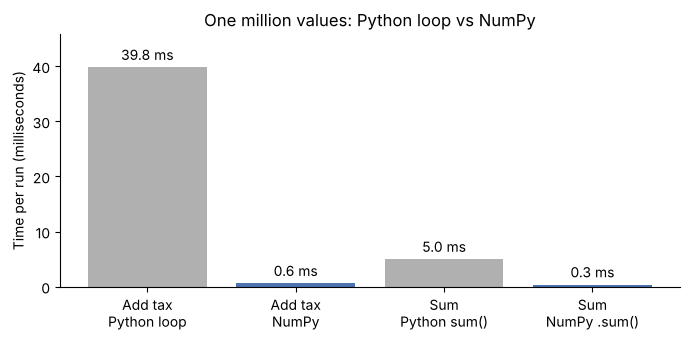

In [51]:
# Chart the four timings (this is the code behind the chapter's figure)
import matplotlib.pyplot as plt

labels = ["Add tax\nPython loop", "Add tax\nNumPy",
          "Sum\nPython sum()", "Sum\nNumPy .sum()"]
ms = [t.average * 1000 for t in (t_loop, t_numpy, t_sum_py, t_sum_np)]
colors = ["#B0B0B0", "#4C72B0", "#B0B0B0", "#4C72B0"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(labels, ms, color=colors)
ax.bar_label(bars, labels=[f"{m:.1f} ms" for m in ms], padding=3)
ax.set_ylabel("Time per run (milliseconds)")
ax.set_title("One million values: Python loop vs NumPy")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(ms) * 1.15)
plt.tight_layout()
fig.savefig("../figures/ch04-speed.png", dpi=150)
plt.show()

### Where does the speed come from?

## 4.9 NumPy inside pandas

You will spend most of the rest of the book in pandas, but NumPy never goes away. Every numeric pandas column wraps a NumPy array, and you can get it back with `.to_numpy()`, as you did earlier. NumPy functions also work directly on pandas columns:

In [52]:
np.round(np.sqrt(sales["revenue"].head()), 2)

0     9.49
1    15.44
2    12.20
3     8.15
4     9.19
Name: revenue, dtype: float64

The result is still a pandas Series, with its row labels kept. And `np.where` is a common way to create a new column from a condition:

In [53]:
sales["size"] = np.where(sales["quantity"] >= 30, "large", "small")
sales[["store", "product", "quantity", "size"]].head()

,store,product,quantity,size
0,Downtown,Espresso,30,large
1,Downtown,Latte,53,large
2,Downtown,Cappuccino,35,large
3,Downtown,Cold Brew,14,small
4,Downtown,Croissant,26,small


## 4.11 Exercises

Open `ch04_numpy.ipynb` and add your answers at the bottom. Solutions are in Appendix D.

1. Create an array of the six Bean There prices. Use a boolean mask to list the prices above $4.00, and count how many there are.
2. Use `np.arange()` to create the days of the week 1 to 7, then use `np.where` to label each day "weekend" if it is 6 or 7 and "weekday" otherwise.
3. Using `week1` from Section 4.5, find the total units sold of each **product** across all three stores. Which product position has the largest total? *Hint:* think about which axis to collapse, then use `.argmax()`.
4. Using `week1_revenue`, what share of each store's first-week revenue came from **bakery** items (the last two columns)? *Hint:* slice the bakery columns, sum along `axis=1`, and divide by the total per store.
5. Using `daily` (the 90 × 3 Latte array), on how many days did Riverside sell more than 30 lattes? *Hint:* Riverside is column 2; sum a boolean array.
6. Bean There wants to compare stores fairly. Divide each column of `daily` by that store's maximum, so every store's best day becomes 1.0. *Hint:* `daily.max(axis=0)` has shape `(3,)`, which broadcasts across the rows.
7. Use a seeded generator (`np.random.default_rng(7)`) to simulate 30 days of Cold Brew sales with `rng.poisson(20, size=30)`. What are the mean, minimum and maximum? Rerun the cell twice. Do the numbers change? Now restart and run the notebook from the top. What happens?
8. **Think about it:** time `np.mean(orders)` against `sum(orders_list) / len(orders_list)` with `%timeit`. Then repeat with only the first 100 values of each. Is NumPy still faster for very small data? Why might that be?